In [5]:
from pathlib import Path

import pandas as pd
import torch
from torch.utils.data import Dataset

DATA_PATH = Path("../data")

folders = [directory for directory in DATA_PATH.iterdir() if directory.is_dir()]

sensfloor_readout_df = pd.read_csv("../data/2025-12-01_12-44-43/sensfloor_readout.csv", sep=",", header=0)

In [6]:
sensfloor_readout_df.head()

,timestamp,frame_number,group_id,magic_number,x,y,0,1,2,3,4,5,6,7
0,3875558667,21,10,23,6,1,128,128,127,127,142,145,129,127
1,4038083917,23,10,23,6,1,128,129,127,127,135,150,131,128
2,4240516250,25,10,23,6,1,128,129,127,127,137,149,130,129
3,4440252750,27,10,23,6,1,128,128,127,127,136,150,131,128
4,4545832375,28,10,23,5,1,128,127,150,132,128,128,127,127


Positions : [[5 1]]
Signals: [[132 128 126 128 136 151 127 127]]


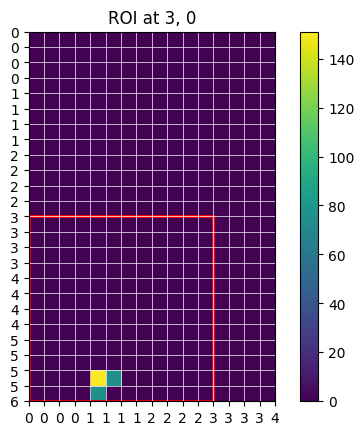

In [7]:
from floor_handler import FloorHandler

floor_handler = FloorHandler(x_size=6, y_size=4, history_len=10, kernel_size=3)

last_frame_number = sensfloor_readout_df["frame_number"].max()
rois = {}

FRAME_NUMBER = 378

messages = sensfloor_readout_df[sensfloor_readout_df["frame_number"] == FRAME_NUMBER]
signals = messages[["0", "1", "2", "3", "4", "5", "6", "7"]].to_numpy()
positions = messages[["x", "y"]].to_numpy() - 1

print(f"Positions : {positions}")
print(f"Signals: {signals}")

floor_handler.update_floor(signals=signals, positions=positions)
rois[f"{FRAME_NUMBER}"] = floor_handler.get_roi()


floor_handler.draw()

In [8]:
floor_handler = FloorHandler(x_size=6, y_size=4, history_len=10, kernel_size=3)

last_frame_number = sensfloor_readout_df["frame_number"].max()
rois = {}

for frame_number in range(last_frame_number):
    messages = sensfloor_readout_df[sensfloor_readout_df["frame_number"] == frame_number]
    signals = messages[["0", "1", "2", "3", "4", "5", "6", "7"]].to_numpy()
    positions = messages[["x", "y"]].to_numpy() - 1
    floor_handler.update_floor(signals=signals, positions=positions)
    rois[f"{frame_number}"] = floor_handler.get_roi()


In [9]:
frame_numbers = sensfloor_readout_df.groupby("frame_number").mean().index.tolist()


for frame_number in frame_numbers:
    messages = sensfloor_readout_df[sensfloor_readout_df["frame_number"] == frame_number]
    break

messages

,timestamp,frame_number,group_id,magic_number,x,y,0,1,2,3,4,5,6,7
0,3875558667,21,10,23,6,1,128,128,127,127,142,145,129,127
